**Set environment**

In [1]:
suppressMessages(suppressWarnings(source("../run_config_project.R")))
show_env()

BASE DIRECTORY (FD_BASE): /hpc/group/igvf/kk319 
REPO DIRECTORY (FD_REPO): /hpc/group/igvf/kk319/repo 
WORK DIRECTORY (FD_WORK): /hpc/group/igvf/kk319/work 
DATA DIRECTORY (FD_DATA): /hpc/group/igvf/kk319/data 

You are working with      IGVF BlueSTARR 
PATH OF PROJECT (FD_PRJ): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR 
PROJECT RESULTS (FD_RES): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results 
PROJECT SCRIPTS (FD_EXE): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/scripts 
PROJECT DATA    (FD_DAT): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/data 
PROJECT NOTE    (FD_NBK): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/notebooks 
PROJECT DOCS    (FD_DOC): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/docs 
PROJECT LOG     (FD_LOG): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/log 
PROJECT REF     (FD_REF): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/references 



## Import data

**Check file existence**

In [2]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard")
vec = dir(txt_fdiry)
for (txt in vec){cat(txt, "\n")}

background_zero_order.npy 
background_zero_order.tsv 
batches_dev 
batches_pilot 
batches_top 
motif_jaspar2024_core_vertebrates_nonredundant.lods.pkl 
motif_jaspar2024_core_vertebrates_nonredundant.pmap.pkl 
motif_jaspar2024_core_vertebrates_nonredundant.tbind.pkl 
motif_nonredundant_jvierstra_v2.1beta.lods.pkl 
motif_nonredundant_jvierstra_v2.1beta.pmap.pkl 
motif_nonredundant_jvierstra_v2.1beta.tbind.pkl 
motifdelta_pilot_jvierstra_v2.1beta 
motifdelta_top_jaspar2024 
motifdelta_top_jvierstra_v2.1beta 
motifmodel_pilot_jvierstra_v2.1beta 
motifscan_pilot_jvierstra_v2.1beta 
motifscan_top_jaspar2024 
motifscan_top_jvierstra_v2.1beta 
variant_closed_gof_bluestarr.flankL35R70.ref.fa 
variant_closed_gof_bluestarr.tsv 


**Import table**

In [3]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard")
txt_fname = "variant_closed_gof_bluestarr.tsv"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
dat = read_tsv(txt_fpath, show_col_types = FALSE)

### assign and show
dat_variant_bluestarr_import = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 1884977      10


Chrom,ChromStart,ChromEnd,Region,Variant_ID,Pos0,Ref,Obs,Unobs,Delta
chr4,74487576,74488141,chr4:74487576-74488141,chr4:74487586:A:G:C,74487586,A,G,C,0.9649841
chr9,135685425,135685942,chr9:135685425-135685942,chr9:135685432:G:G:C,135685432,G,G,C,0.9454227
chr1,173251481,173251541,chr1:173251481-173251541,chr1:173251490:G:G:C,173251490,G,G,C,0.9101272


## Explore

### Summarize the Delta

In [4]:
dat = dat_variant_bluestarr_import
summary(dat$Delta)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.000000 0.002268 0.005376 0.008106 0.010677 0.964984 

### Histogram of Delta

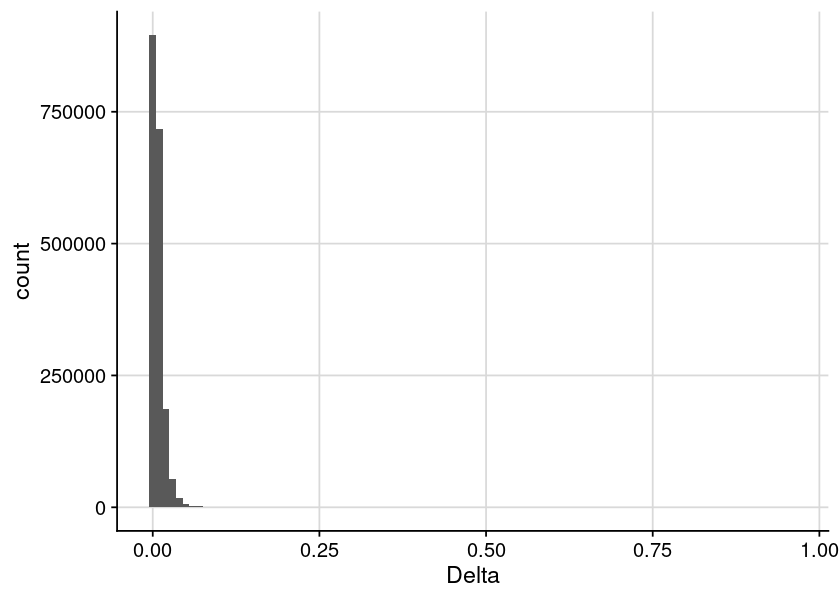

In [5]:
dat = dat_variant_bluestarr_import
gpt = ggplot(dat, aes(x = Delta)) + 
    geom_histogram(binwidth = 0.01) + 
    theme_cowplot() +
    background_grid()
options(repr.plot.height=5, repr.plot.width=7)
print(gpt)

**Set exported plot**

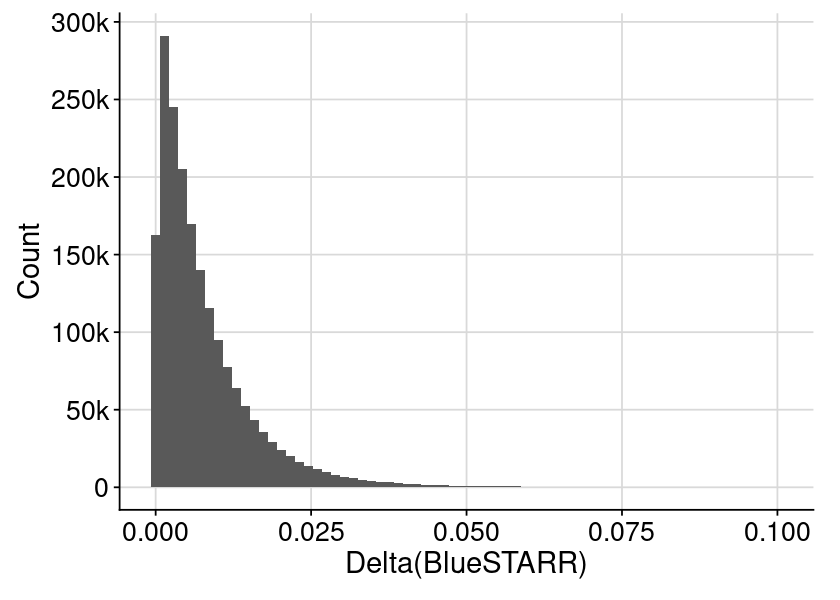

In [6]:
fun_label_km <- function(x) {
  sapply(x, function(v) {
    if (is.na(v)) return(NA_character_)
    if (v < 1e3) return(as.character(v))        # 0, 500, etc.
    if (v < 1e6) return(paste0(round(v / 1e3), "k"))
    paste0(format(round(v / 1e6, 1), trim = TRUE), "M")
  })
}

dat = dat_variant_bluestarr_import
dat = dat %>% dplyr::filter(Delta < 0.1)

gpt = ggplot(dat, aes(x = Delta)) + 
    geom_histogram(bins = 70) + 
    theme_pub(base_size = 16) +
    scale_y_continuous(
        labels = fun_label_km,
        breaks = scales::pretty_breaks(5)
    ) +
    labs(x = "Delta(BlueSTARR)", y = "Count")

options(repr.plot.height=5, repr.plot.width=7)
print(gpt)

### Delta in descending order

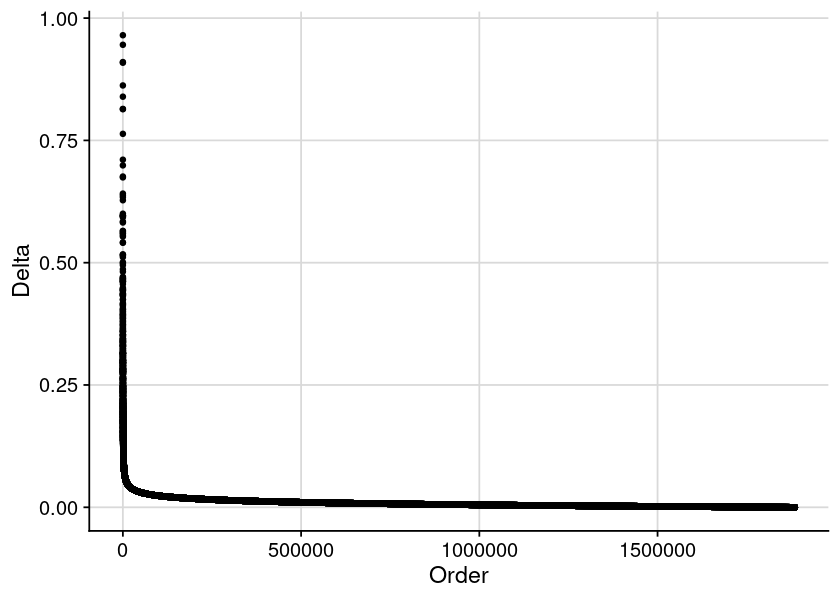

In [7]:
dat = dat_variant_bluestarr_import
dat = dat %>% dplyr::mutate(Order = row_number())

gpt = ggplot(dat, aes(x = Order, y = Delta)) + 
    geom_point(size = 1) + 
    theme_cowplot() +
    background_grid()

options(repr.plot.height=5, repr.plot.width=7)
print(gpt)

**Set exported plot**

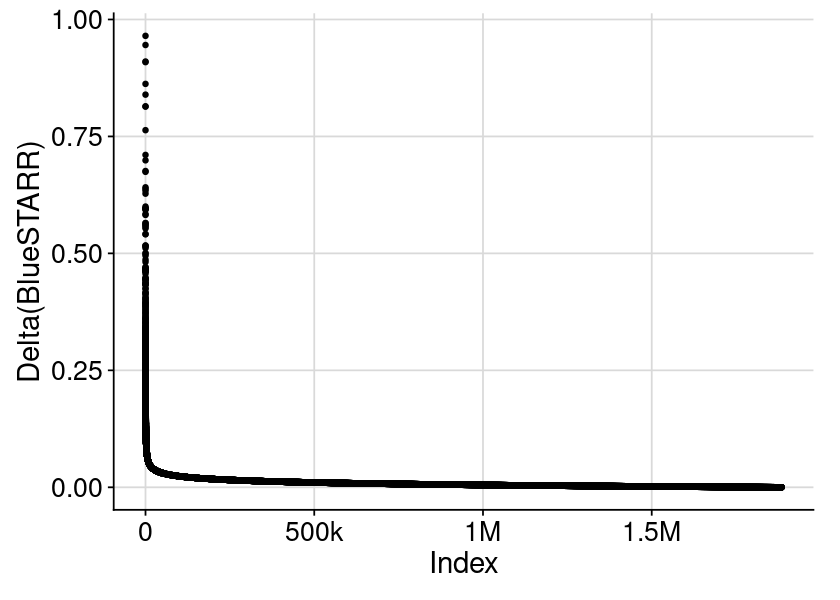

In [8]:
dat = dat_variant_bluestarr_import
dat = dat %>% dplyr::mutate(Order = row_number())

num_keep = 50000
num_step = 100   # keep 1 out of 50 in the bulk

dat = bind_rows(
    dat %>% slice(1:num_keep),
    dat %>% slice(seq(num_keep + 1, n(), by = num_step))
)

fun_label_km <- function(x) {
  sapply(x, function(v) {
    if (is.na(v)) return(NA_character_)
    if (v < 1e3) return(as.character(v))        # 0, 500, etc.
    if (v < 1e6) return(paste0(round(v / 1e3), "k"))
    paste0(format(round(v / 1e6, 1), trim = TRUE), "M")
  })
}

gpt = ggplot(dat, aes(x = Order, y = Delta)) + 
    geom_point(size = 1) + 
    theme_pub(base_size = 16) +
    scale_x_continuous(
        labels = fun_label_km,
        breaks = scales::pretty_breaks(5)
    ) +
    labs(x = "Index", y = "Delta(BlueSTARR)")

options(repr.plot.height=5, repr.plot.width=7)
print(gpt)

## Justify top 100k variants is enough for downstream analysis

In [9]:
num_cut = 1e5

dat = dat_variant_bluestarr_import 
dat = dat %>% dplyr::arrange(desc(Delta))
dat = tibble(
    Top_variants           = num_cut,
    Fraction_Total_Delta   = sum(dat$Delta[1:num_cut]) / sum(dat$Delta),
    Max_Delta_Remaining    = max(dat$Delta[-(1:num_cut)]),
    Median_Delta_Remaining = median(dat$Delta[-(1:num_cut)])
)

fun_display_table(dat)

Top_variants,Fraction_Total_Delta,Max_Delta_Remaining,Median_Delta_Remaining
1e+05,0.2405562,0.023612,0.004979


### Summarize top 100k variants and the remaining variants

The top 100k variants capture the full Δ dynamic range, while remaining variants are uniformly low-effect.

Across all variants, Delta(BlueSTARR) values range from 0 to 0.96. The top 100k variants include the full observed Δ range (max Δ = 0.96), whereas variants outside this set are restricted to much smaller effect sizes (maximum Δ ≈ 0.024; median Δ ≈ 0.005), indicating that the remaining variants are having a narrow low effect.

In [14]:
num_cut = 1e5

dat = dat_variant_bluestarr_import 
dat = dat %>% dplyr::arrange(desc(Delta))
dat = tibble(
    Max_delta_total   = max(dat$Delta),
    Max_Delta_top100k = max(dat$Delta[1:num_cut]),
    Min_Delta_top100k = min(dat$Delta[1:num_cut]),
    Max_Delta_Remaining    = max(dat$Delta[-(1:num_cut)]),
    Median_Delta_Remaining = median(dat$Delta[-(1:num_cut)])
)

fun_display_table(dat)

Max_delta_total,Max_Delta_top100k,Min_Delta_top100k,Max_Delta_Remaining,Median_Delta_Remaining
0.9649841,0.9649841,0.0236121,0.023612,0.004979


### Rank-ordered distribution of Delta values in log scale
The dashed vertical line marks the modeling cutoff at 100k variants. After 100k, the curve flattens, showing that most additional variants have progressively smaller effects.

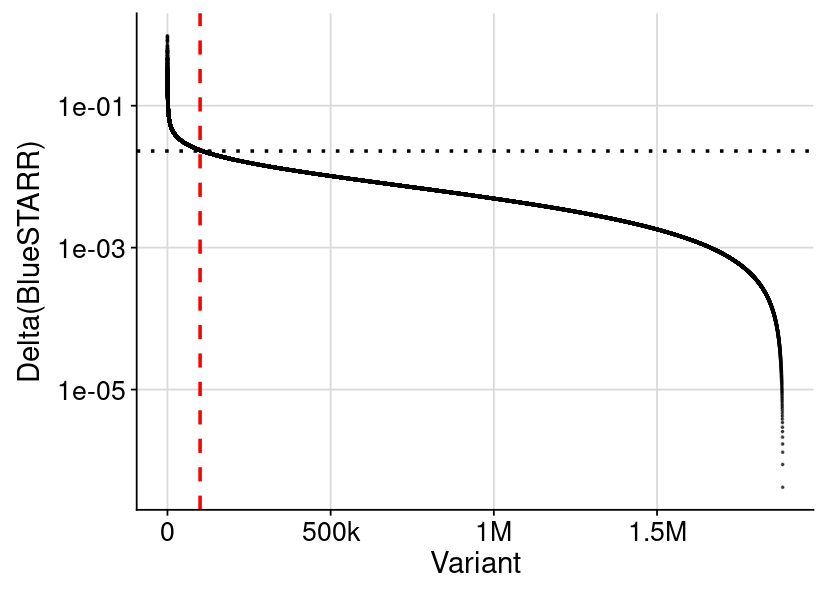

In [17]:
num_keep = 200000   # dense tail
num_step = 100       # aggressive downsample elsewhere
num_cut  = 1e5

dat = dat_variant_bluestarr_import
dat = dat %>%
    dplyr::filter(Delta > 0) %>%
    dplyr::arrange(desc(Delta)) %>%
    dplyr::mutate(Rank = row_number())

dat = bind_rows(
    dat %>% dplyr::slice(1:num_keep),
    dat %>% dplyr::slice(seq(num_keep + 1, n(), by = num_step))
)

num_delta = max(dat$Delta[dat$Rank > num_cut])

gpt = ggplot(dat, aes(Rank, Delta)) +
    geom_point(size = 0.2, alpha = 0.6) +
    geom_vline(xintercept = num_cut,   linewidth=1.0, linetype = "dashed", color = "red") +
    geom_hline(yintercept = 0.023, linewidth=1.0, linetype = "dotted") +
    scale_y_log10() +
    scale_x_continuous(labels = fun_label_km) +
    theme_pub(base_size = 16) +
    labs(x = "Variant", y = "Delta(BlueSTARR)")

options(repr.plot.height=5, repr.plot.width=7)
print(gpt)

### Quantile analysis
Between 100k and 200k variants, the median Delta decreases from 0.030 to 0.024 and the 95th percentile decreases from 0.066 to 0.052, indicating limited additional coverage of higher-effect relative to the increase in data volume.

In [70]:
quantiles = c(0.5, 0.75, 0.9, 0.95, 0.99)

cuts = c(1e4, 5e4, 1e5, 2e5, 5e5)
dat = dat_variant_bluestarr_import
dat = lapply(cuts, function(cut) {
    qs  = quantile(dat$Delta[1:cut], probs = quantiles)
    tibble(
        cutoff = cut,
        q = quantiles,
        Delta = as.numeric(qs)
    )
}) |> bind_rows()
dat

cutoff,q,Delta
<dbl>,<dbl>,<dbl>
1e+04,0.50,0.06584918
1e+04,0.75,0.08642673
1e+04,0.90,0.12852474
1e+04,0.95,0.17905189
1e+04,0.99,0.35295340
5e+04,0.50,0.03832185
5e+04,0.75,0.04802541
5e+04,0.90,0.06584903
5e+04,0.95,0.08642658
